# <font color="darkblue"> Prática 01: Classificação binária com Redes Neurais </font>

**Objetivos:**


*   Utilizar a API Keras para classificação binária com redes neurais.

**Descrição:**

Com base em informações fornecidadas de 303 pessoas, as quais incluem idade, pressão arterial, nível de colesterol, frequência cardíaca, entre outras, implemente uma rede neural para prever as chances de um indivíduo ter um infarto. 

# <font color="darkblue"> Solução </font>

### Bibliotecas

In [2]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import keras

print('Python: {}'.format(sys.version))
print('Pandas: {}'.format(pd.__version__))
print('Numpy: {}'.format(np.__version__))
print('Sklearn: {}'.format(sklearn.__version__))
print('Matplotlib: {}'.format(matplotlib.__version__))
print('Keras: {}'.format(keras.__version__))

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 08:03:38) [Clang 14.0.6 ]
Pandas: 2.3.2
Numpy: 2.0.1
Sklearn: 1.7.1
Matplotlib: 3.10.5
Keras: 3.11.2


### Leitura das instâncias

In [3]:
BATCH_SIZE = 16
RANDOM_STATE = 2

data = pd.read_csv("heart.csv")

X = np.array(data.drop(['output'], axis=1))
y = np.array(data['output'])
np.shape(X)

(303, 13)

### Explorando os dados

In [4]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

print(f"Shape: {data.shape}")
data.head()

Shape: (303, 14)


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


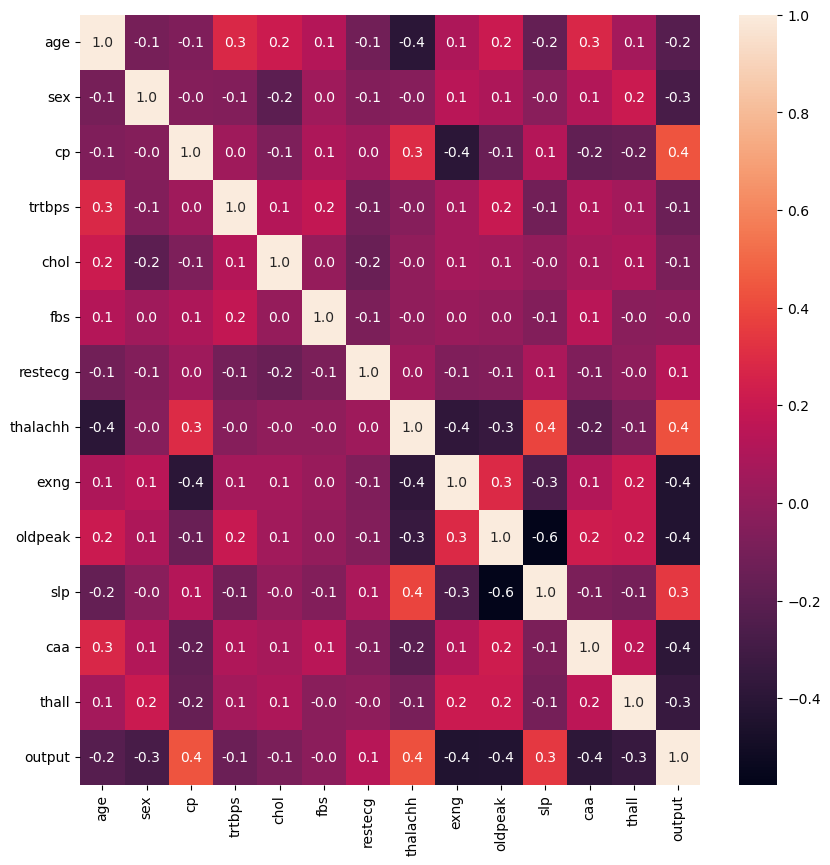

In [5]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True, fmt='.1f')
plt.show()

### Criando a rede neural 

<p>
Considerando a criação de uma rede neural com apenas uma camada escondida, podemos usar a fórmula abaixo para definir seu número máximo $n$ de neurônios: </p>

<br>

<span style="font-size: 20px">
 $n \le \lfloor \frac{\lvert DS \rvert - 10}{10\times (d+2)} \rfloor  $ 
</span>

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection

# Padronizacao de dados
'''
mean = X.mean(axis=0)
std = X.std(axis=0)
X -= mean
X /= std
'''

# Normalizacao de dados
min_values = X.min(axis=0)
max_values = X.max(axis=0)
X = (X - min_values) / (max_values - min_values)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

print(f'Training set size: {len(X_train)}')

# Criando a arquitetura da rede neural
model = Sequential()

# Camada de entrada
model.add(Input(shape=(13,)))

# Rede configurada a partir de informações da dimensão VC e da regra de ouro
model.add(Dense(2, kernel_initializer='normal', activation='tanh'))
model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

# Gradiente Descendente
sgd = optimizers.SGD(learning_rate=0.01)  

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

print(model.summary())

Training set size: 242


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Treinando a rede neural


In [7]:
model.set_weights(initial_weights)
history = model.fit(X_train, y_train, epochs=100, batch_size=BATCH_SIZE)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.6936  
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5620 - loss: 0.6932
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5620 - loss: 0.6929
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5620 - loss: 0.6923 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5620 - loss: 0.6919
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5620 - loss: 0.6914 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.5620 - loss: 0.6907
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.5620 - loss: 0.6903
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.5620 - loss: 0.6900
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.5620 - loss: 0.6896
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.5620 - loss: 0.6891
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/

### Performance do modelo

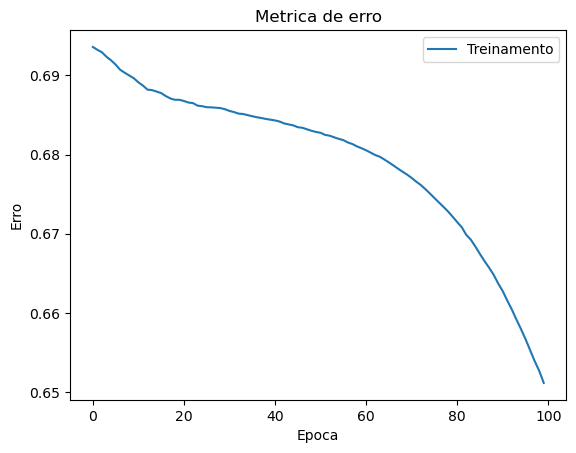


--> Acuracia (treino): 0.5620
--> Acuracia (teste): 0.4754
--> E_out - E_in = 0.0131
--> acc_train - acc_test = 0.0866


In [8]:
from sklearn.metrics import accuracy_score

plt.plot(history.history['loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, verbose=0)

# Obtendo a acuracia no conjunto de teste
E_out, acc_test = model.evaluate(X_test, y_test, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> E_out - E_in = {E_out - E_in:.4f}")
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

### Testando outras arquiteturas e hiperparâmetros

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from sklearn import model_selection

X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, random_state=RANDOM_STATE, test_size=0.2)

# Criando a arquitetura da rede neural
model = Sequential()

# Camada de entrada
model.add(Input(shape=(13,)))
model.add(Dense(80, kernel_initializer='he_normal', activation='relu'))
model.add(Dense(80, kernel_initializer='he_normal', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 80)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 80)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,681 (30.00 KB)

 Trainable params: 7,681 (30.00 KB)

 Non-trainable params: 0 (0.00 B)

None


### Treinamento do novo modelo

In [10]:
model.set_weights(initial_weights)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=BATCH_SIZE)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6321 - loss: 0.6473 - val_accuracy: 0.7143 - val_loss: 0.6256
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7358 - loss: 0.5604 - val_accuracy: 0.7755 - val_loss: 0.5520
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7617 - loss: 0.5243 - val_accuracy: 0.8163 - val_loss: 0.5014
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7565 - loss: 0.4939 - val_accuracy: 0.8163 - val_loss: 0.4746
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7720 - loss: 0.4675 - val_accuracy: 0.7959 - val_loss: 0.4415
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8238 - loss: 0.4571 - val_accuracy: 0.7755 - val_loss: 0.4322
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8342 - loss: 0.4368 - val_accuracy: 0.7959 - val_loss: 0.3983
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8031 - loss: 0.4170 - val_accuracy: 0.8367 - v

### Performance do novo modelo

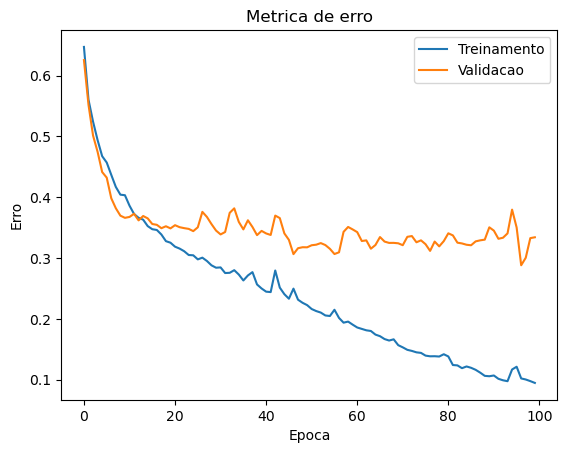

--> E_val - E_in = 0.2380
--> Acuracia (treino): 0.9793
--> Acuracia (validacao): 0.7959
--> acc_train - acc_test = 0.1834


In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

### Usando validacao para verificar se ha overfitting

### Tratando o overfitting

In [12]:
from keras.layers import Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

# Criando a arquitetura da rede neural
model = Sequential()

model.add(Input(shape=(13,)))
model.add(Dense(50, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.1), activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(50, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.1), activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,301 (12.89 KB)

 Trainable params: 3,301 (12.89 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
model.set_weights(initial_weights)

#history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=BATCH_SIZE, callbacks=[es])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=BATCH_SIZE)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5337 - loss: 19.4060 - val_accuracy: 0.5714 - val_loss: 18.5507
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5389 - loss: 17.9490 - val_accuracy: 0.6327 - val_loss: 17.1577
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5959 - loss: 16.6159 - val_accuracy: 0.6939 - val_loss: 15.8844
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6373 - loss: 15.3890 - val_accuracy: 0.6327 - val_loss: 14.7229
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6528 - loss: 14.2696 - val_accuracy: 0.6939 - val_loss: 13.6545
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6943 - loss: 13.2453 - val_accuracy: 0.7143 - val_loss: 12.6806
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6736 - loss: 12.3087 - val_accuracy: 0.6939 - val_loss: 11.7861
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6891 - loss: 11.4443 - val_accur

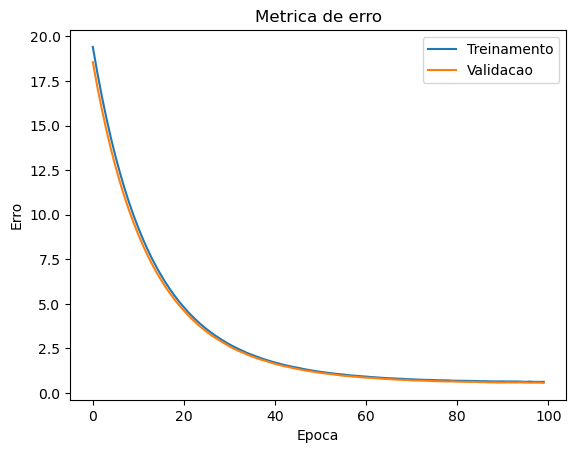

--> E_val - E_in = -0.0560
--> Acuracia (treino): 0.8031
--> Acuracia (validacao): 0.8776
--> acc_train - acc_test = -0.0744


In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

### Treinando a rede usando k-fold cross validation

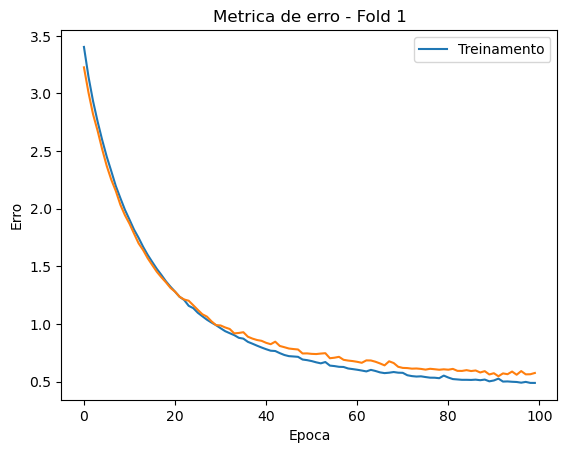

--> Acuracia (treino): 0.8497
--> Acuracia (validacao): 0.8367
--> E_val - E_in = 0.0906
--> acc_in - acc_val = 0.0130



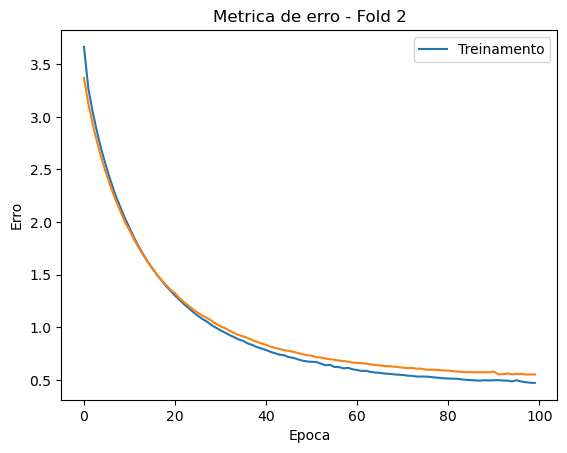

--> Acuracia (treino): 0.8601
--> Acuracia (validacao): 0.7959
--> E_val - E_in = 0.0841
--> acc_in - acc_val = 0.0642



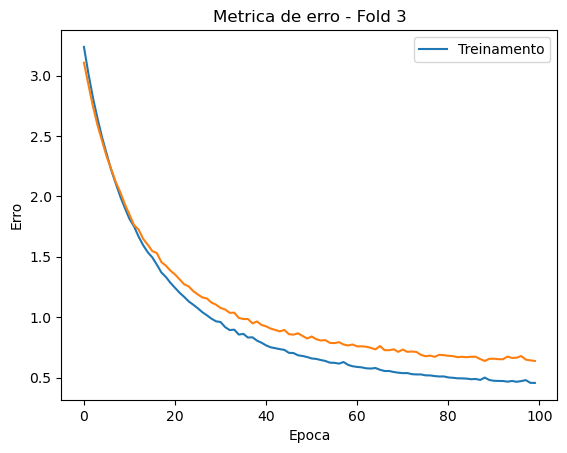

--> Acuracia (treino): 0.8711
--> Acuracia (validacao): 0.7708
--> E_val - E_in = 0.1847
--> acc_in - acc_val = 0.1003



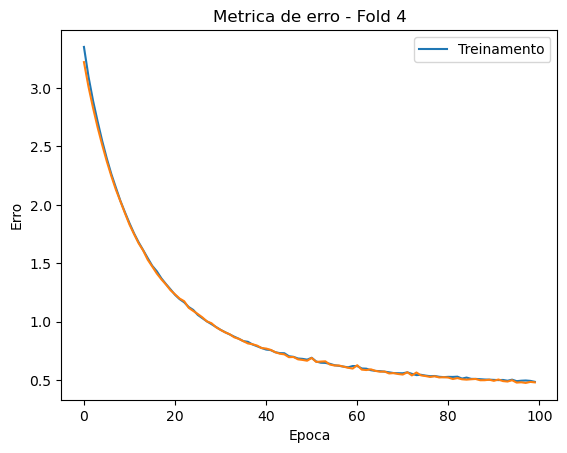

--> Acuracia (treino): 0.8402
--> Acuracia (validacao): 0.8750
--> E_val - E_in = -0.0006
--> acc_in - acc_val = -0.0348



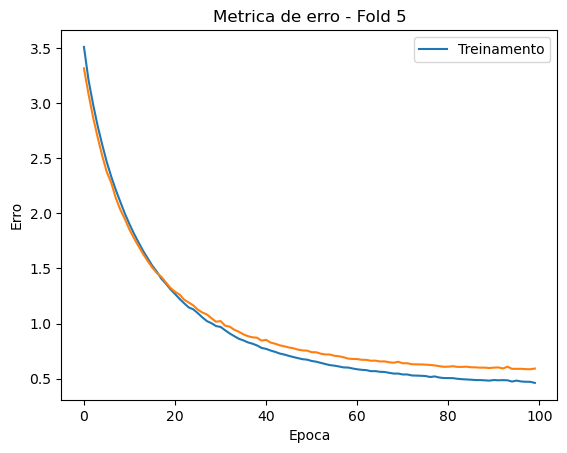

--> Acuracia (treino): 0.8660
--> Acuracia (validacao): 0.7708
--> E_val - E_in = 0.1249
--> acc_in - acc_val = 0.0951



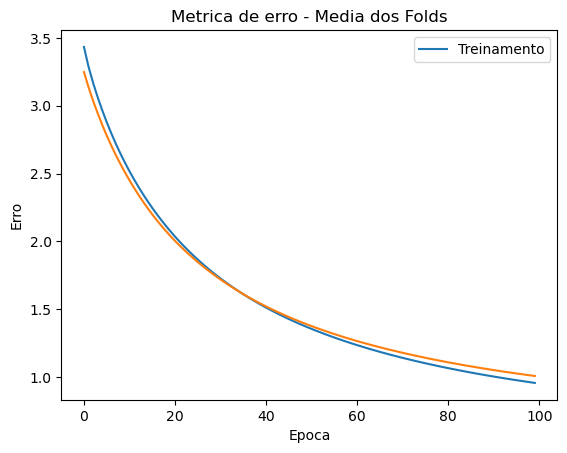

--> Acuracia (treino): 0.8574
--> Acuracia (validacao): 0.8099
--> E_in = 0.4704
--> E_val = 0.5672
--> E_val - E_in = 0.0967
--> acc_in - acc_val = 0.0476



In [23]:
from sklearn.model_selection import StratifiedKFold

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

# Garante o balanceamento nos folds
skf = StratifiedKFold(n_splits=5, shuffle=True)

accuracies_train = []
accuracies_val = []
history_list = []
ein_list = []
eval_list = []

# Realiza o k-fold cross validation
i = 0
for train_index, val_index in skf.split(X_train, y_train):
    i = i + 1
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    
    # Criando a arquitetura da rede neural    
    model = Sequential()

    model.add(Input(shape=(13,)))
    
    # Model 1    
    model.add(Dense(70, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(70, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))
        
    # Model 2
    '''
    model.add(Dense(2, kernel_initializer='he_normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))
    '''
    
    # Compilar o modelo
    model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
  
    # Treina o modelo
    history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), epochs=100, batch_size=BATCH_SIZE, verbose=0)
    history_list.append(history) 
    
    # Avalia o modelo
    E_in, accuracy_train = model.evaluate(X_train_fold, y_train_fold, batch_size=BATCH_SIZE, verbose=0)
    E_val, accuracy_val = model.evaluate(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, verbose=0)
    
    accuracies_train.append(accuracy_train)
    accuracies_val.append(accuracy_val)
    ein_list.append(E_in)
    eval_list.append(E_val)    
    
    # Exibe o historico de treinamento para um fold especifico
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Metrica de erro - Fold {i}')
    plt.ylabel('Erro')
    plt.xlabel('Epoca')
    plt.legend(['Treinamento'])
    plt.show()

    print(f'--> Acuracia (treino): {accuracy_train:.4f}')
    print(f'--> Acuracia (validacao): {accuracy_val:.4f}')
    print(f"--> E_val - E_in = {E_val - E_in:.4f}")
    print(f"--> acc_in - acc_val = {accuracy_train - accuracy_val:.4f}\n")    

# Calcula a acuracia media
avg_accuracy_train = np.mean(accuracies_train)
avg_accuracy_val = np.mean(accuracies_val)
avg_ein = np.mean(ein_list)
avg_eval = np.mean(eval_list)

# Historico com valores medios dos folds
history_loss_avg = []
history_val_loss_avg = []
aux_list1 = []
aux_list2 = []

for i in range(len(history.history['loss'])):
    for j in range(len(history_list)):
        aux_list1.append(history_list[j].history['loss'][i])
        aux_list2.append(history_list[j].history['val_loss'][i])
    history_loss_avg.append(np.mean(aux_list1))
    history_val_loss_avg.append(np.mean(aux_list2))                            
                   
plt.plot(history_loss_avg)
plt.plot(history_val_loss_avg)
plt.title('Metrica de erro - Media dos Folds')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

print(f'--> Acuracia (treino): {avg_accuracy_train:.4f}')
print(f'--> Acuracia (validacao): {avg_accuracy_val:.4f}')
print(f"--> E_in = {avg_ein:.4f}")
print(f"--> E_val = {avg_eval:.4f}")
print(f"--> E_val - E_in = {avg_eval - avg_ein:.4f}")
print(f"--> acc_in - acc_val = {avg_accuracy_train - avg_accuracy_val:.4f}\n")    

In [15]:
# Obtendo a acuracia no conjunto de teste
E_out, acc_test = model.evaluate(X_test, y_test, verbose=0)

print(f"--> E_out = {E_out:.4f}")
print(f'--> Acuracia (teste): {acc_test:.4f}')

--> E_out = 0.3997
--> Acuracia (teste): 0.8689


### Implementando um grid search manualmente

In [24]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from itertools import product

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

# Garante o balanceamento nos folds
skf = StratifiedKFold(n_splits=5, shuffle=True)

# Define o grid de parâmetros
param_grid = {
    "neurons": [2, 50],
    "l2_reg": [0.01, 0.1],
    "dropout": [0.0, 0.2],
    "batch_size": [16, 32],
    "epochs": [100]
}

# Gera todas as combinações
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

best_val_acc = -1
best_params = None

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    print(f"\n===== Testando parâmetros: {params} =====")

    accuracies_train = []
    accuracies_val = []
    history_list = []
    ein_list = []
    eval_list = []

    i = 0
    for train_index, val_index in skf.split(X_train, y_train):
        i += 1
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Cria a arquitetura da rede neural
        model = Sequential()
        model.add(Input(shape=(13,)))   

        # Camada 1    
        model.add(Dense(params["neurons"], 
                        kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(params["l2_reg"]),
                        activation='relu'))
        
        if params["dropout"] > 0:
            model.add(Dropout(params["dropout"]))
            
        # Camada 2    
        model.add(Dense(params["neurons"], kernel_initializer='he_normal',
                        kernel_regularizer=regularizers.l2(params["l2_reg"]),
                        activation='relu'))
        
        if params["dropout"] > 0:
            model.add(Dropout(params["dropout"]))

        # Camada de saída
        model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

        # Compila o modelo
        model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

        # Treina o modelo
        history = model.fit(X_train_fold, y_train_fold,
                            validation_data=(X_val_fold, y_val_fold),
                            epochs=params["epochs"], batch_size=params["batch_size"], verbose=0)
        history_list.append(history)

        # Avaliação do modelo
        E_in, accuracy_train = model.evaluate(X_train_fold, y_train_fold, batch_size=params["batch_size"], verbose=0)
        E_val, accuracy_val = model.evaluate(X_val_fold, y_val_fold, batch_size=params["batch_size"], verbose=0)

        accuracies_train.append(accuracy_train)
        accuracies_val.append(accuracy_val)
        ein_list.append(E_in)
        eval_list.append(E_val)

        print(f'Fold {i}: train acc={accuracy_train:.4f}, val acc={accuracy_val:.4f}')

    # Calcula a acuracia média
    avg_accuracy_train = np.mean(accuracies_train)
    avg_accuracy_val = np.mean(accuracies_val)

    print(f"\n>>> Parâmetros: {params}")
    print(f"--> Avg train acc = {avg_accuracy_train:.4f}")
    print(f"--> Avg val acc   = {avg_accuracy_val:.4f}")

    # Encontra os melhores parâmetros
    if avg_accuracy_val > best_val_acc:
        best_val_acc = avg_accuracy_val
        best_params = params

print("\n==============================")
print(f"Melhores parâmetros: {best_params}")
print(f"Melhor acurácia na validação: {best_val_acc:.4f}")

# -----------------------------
# Retreina o modelo no conjunto de treinamento completo com os melhores parâmetros
# -----------------------------
print("\nTreinando a rede com os melhores parâmetros no conjunto de treinamento completo...")
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(best_params['neurons'], 
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(best_params["l2_reg"]),
                activation='relu'))

if best_params["dropout"] > 0:
    model.add(Dropout(best_params["dropout"]))

model.add(Dense(best_params['neurons'], 
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(best_params["l2_reg"]),
                activation='relu'))

if best_params["dropout"] > 0:
    model.add(Dropout(best_params["dropout"]))


model.add(Dense(best_params['neurons'], 
                kernel_initializer='he_normal',
                kernel_regularizer=regularizers.l2(best_params["l2_reg"]),
                activation='relu'))

if best_params["dropout"] > 0:
    model.add(Dropout(best_params["dropout"]))

model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

model.fit(X_train, y_train,
          epochs=best_params["epochs"],
          batch_size=best_params["batch_size"],
          verbose=0)

# Avalia a rede no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=best_params["batch_size"], verbose=0)
print(f"\nTrain set -> Loss: {E_in:.4f}, Accuracy: {acc_train:.4f}")

# Avalia a rede no conjunto de teste
E_test, acc_test = model.evaluate(X_test, y_test, batch_size=best_params["batch_size"], verbose=0)
print(f"\nTest set -> Loss: {E_test:.4f}, Accuracy: {acc_test:.4f}")


===== Testando parâmetros: {'neurons': 2, 'l2_reg': 0.01, 'dropout': 0.0, 'batch_size': 16, 'epochs': 100} =====
Fold 1: train acc=0.8083, val acc=0.8571
Fold 2: train acc=0.5596, val acc=0.5714
Fold 3: train acc=0.8093, val acc=0.8542
Fold 4: train acc=0.7938, val acc=0.7917
Fold 5: train acc=0.8299, val acc=0.7500

>>> Parâmetros: {'neurons': 2, 'l2_reg': 0.01, 'dropout': 0.0, 'batch_size': 16, 'epochs': 100}
--> Avg train acc = 0.7602
--> Avg val acc   = 0.7649

===== Testando parâmetros: {'neurons': 2, 'l2_reg': 0.01, 'dropout': 0.0, 'batch_size': 32, 'epochs': 100} =====
Fold 1: train acc=0.7927, val acc=0.7755
Fold 2: train acc=0.6891, val acc=0.6735
Fold 3: train acc=0.5619, val acc=0.5625
Fold 4: train acc=0.5619, val acc=0.5625
Fold 5: train acc=0.8144, val acc=0.6667

>>> Parâmetros: {'neurons': 2, 'l2_reg': 0.01, 'dropout': 0.0, 'batch_size': 32, 'epochs': 100}
--> Avg train acc = 0.6840
--> Avg val acc   = 0.6481

===== Testando parâmetros: {'neurons': 2, 'l2_reg': 0.01, '

### Usando o grid search do scikit-learn

In [25]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers

# Função para criar a arquitetura da rede neural
def create_model(neurons=30, l2_reg=0.01, dropout=0.0):
    model = Sequential()
    
    model.add(Input(shape=(13,)))
    
    model.add(Dense(neurons, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(l2_reg)))
    if dropout > 0:
        model.add(Dropout(dropout))
    
    model.add(Dense(neurons, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(l2_reg)))
    if dropout > 0:
        model.add(Dropout(dropout))

    model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

# Divide os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, test_size=0.2)

# Cria o classificador com valores default
keras_classifier = KerasClassifier(
    model = create_model,  
    model__neurons = 30,   
    model__l2_reg = 0.01,  
    model__dropout = 0.0,
    verbose = 0
)

# Define o grid de hiperparâmetros
param_grid = {
    'model__neurons': [2, 50],
    'model__l2_reg': [0.01, 0.1],
    'model__dropout': [0.0, 0.2],
    'batch_size': [16],
    'epochs': [100]
}

# Grid search com 5-fold CV
print("\n**************************\n")
print("--> Início do treinamento")
grid = GridSearchCV(estimator = keras_classifier, param_grid = param_grid, cv = 5)
grid_result = grid.fit(X_train, y_train)

# Melhores parâmetros
print("\nMelhor acurácia: %.4f usando %s" % (grid_result.best_score_, grid_result.best_params_))

# -----------------------------
# Retreina o modelo com os melhores hiperparâmetros no conjunto de treinamento completo
# -----------------------------
best_params = grid_result.best_params_
print("\nRetreinando com os melhores hiperparâmetros:", best_params)

# Cria o modelo com os melhores hiperparâmetros
best_model = create_model(neurons=best_params['model__neurons'], l2_reg=best_params['model__l2_reg'], dropout=best_params['model__dropout'])

# Treina o modelo
best_model.fit(
    X_train, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=0
)

# Avalia a rede no conjunto de treinamento
E_in, acc_train = best_model.evaluate(X_train, y_train, verbose=0)
print(f"\nTrain set -> Loss: {E_in:.4f}, Accuracy: {acc_train:.4f}")

# Avalia o modelo no conjunto de teste
E_test, acc_test = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest set -> Loss: {E_test:.4f}, Accuracy: {acc_test:.4f}")
print("\n**************************\n")


**************************

--> Início do treinamento

Melhor acurácia: 0.8429 usando {'batch_size': 16, 'epochs': 100, 'model__dropout': 0.2, 'model__l2_reg': 0.01, 'model__neurons': 50}

Retreinando com os melhores hiperparâmetros: {'batch_size': 16, 'epochs': 100, 'model__dropout': 0.2, 'model__l2_reg': 0.01, 'model__neurons': 50}

Train set -> Loss: 0.4238, Accuracy: 0.8884

Test set -> Loss: 0.6304, Accuracy: 0.7869

**************************

